# 🧠 Explainable Spatiotemporal Deepfake Detection
### CNN–ViT–BiLSTM Fusion for Social Media Security

**Dataset:** FaceForensics++ C23 (Kaggle)

**Novel contributions over Soudy et al. (2024):**
- ✅ BiLSTM + Transformer temporal modeling
- ✅ Grad-CAM++ explainability
- ✅ Multi-manipulation-type evaluation
- ✅ Social media compression robustness
- ✅ Adversarial robustness (FGSM)

---
**Runtime:** GPU (T4 recommended) | **Est. training time:** ~2–3 hours


## ⚙️ 1 — GPU Check & Setup

In [2]:
import torch
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


## 🔑 2 — Google Drive Authentication & Download

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Verify your zip is visible
import os
DATA_ROOT = '/content/drive/MyDrive/subset_10pct'  # adjust path if needed
print('Found ✅' if os.path.exists(DATA_ROOT) else '❌ Not found')

Mounted at /content/drive
Found ✅


In [5]:
from pathlib import Path

DATA_ROOT = Path('/content/drive/MyDrive/subset_10pct')

for item in sorted(DATA_ROOT.rglob('*')):
    # Show only first 3 files per folder to avoid flooding output
    relative = item.relative_to(DATA_ROOT)
    depth    = len(relative.parts)
    
    # Count siblings to show "... and X more"
    if item.is_file():
        siblings = list(item.parent.glob('*'))
        if siblings.index(item) >= 3:
            if siblings.index(item) == 3:
                total = len(siblings)
                indent = '    ' * (depth - 1)
                print(f"{indent}    ... and {total - 3} more {item.suffix} files")
            continue
    
    indent = '    ' * (depth - 1)
    icon   = '📁' if item.is_dir() else '📄'
    print(f"{indent}{icon} {item.name}")

📁 DeepFakeDetection
    📄 01_11__talking_against_wall__UQ0BOBNO.mp4
    📄 01_15__kitchen_still__02HILKYO.mp4
    📄 01_27__walking_outside_cafe_disgusted__ZYCZ30C0.mp4
        ... and 97 more .mp4 files
📁 Deepfakes
    📄 024_073.mp4
        ... and 97 more .mp4 files
    📄 032_944.mp4
    📄 034_590.mp4
📁 Face2Face
    📄 013_883.mp4
        ... and 97 more .mp4 files
    📄 021_312.mp4
    📄 025_067.mp4
📁 FaceShifter
    📄 004_982.mp4
    📄 017_803.mp4
    📄 019_018.mp4
        ... and 97 more .mp4 files
📁 FaceSwap
        ... and 97 more .mp4 files
    📄 017_803.mp4
    📄 024_073.mp4
    📄 035_036.mp4
📁 NeuralTextures
        ... and 97 more .mp4 files
    📄 033_097.mp4
    📄 034_590.mp4
    📄 035_036.mp4
📁 csv
    📄 Deepfakes.csv
    📄 FF++_Metadata_Shuffled.csv
        ... and 7 more .csv files
    📄 original.csv
📁 original
    📄 002.mp4
    📄 004.mp4
    📄 007.mp4
        ... and 97 more .mp4 files


In [6]:
import pandas as pd
from pathlib import Path

DATA_ROOT = Path('/content/drive/MyDrive/subset_10pct')
CSV_DIR   = DATA_ROOT / 'csv'

# ── 1. Peek at the main metadata file ──
print('='*60)
print('FF++_Metadata.csv')
print('='*60)
df_meta = pd.read_csv(CSV_DIR / 'FF++_Metadata.csv')
print('Shape     :', df_meta.shape)
print('Columns   :', list(df_meta.columns))
print('Dtypes:\n', df_meta.dtypes)
print('\nFirst 5 rows:')
print(df_meta.head())
print('\nValue counts per column:')
for col in df_meta.columns:
    if df_meta[col].nunique() < 20:
        print(f'\n  {col}:')
        print(df_meta[col].value_counts())

# ── 2. Peek at one type-specific CSV ──
print('\n' + '='*60)
print('Deepfakes.csv')
print('='*60)
df_deep = pd.read_csv(CSV_DIR / 'Deepfakes.csv')
print('Shape     :', df_deep.shape)
print('Columns   :', list(df_deep.columns))
print('\nFirst 5 rows:')
print(df_deep.head())

# ── 3. Peek at original.csv ──
print('\n' + '='*60)
print('original.csv')
print('='*60)
df_orig = pd.read_csv(CSV_DIR / 'original.csv')
print('Shape     :', df_orig.shape)
print('Columns   :', list(df_orig.columns))
print('\nFirst 5 rows:')
print(df_orig.head())

# ── 4. Peek at Mean_Data.csv ──
print('\n' + '='*60)
print('Mean_Data.csv')
print('='*60)
df_mean = pd.read_csv(CSV_DIR / 'Mean_Data.csv')
print('Shape     :', df_mean.shape)
print(df_mean)

FF++_Metadata.csv
Shape     : (700, 8)
Columns   : ['Unnamed: 0', 'File Path', 'Label', 'Frame Count', 'Width', 'Height', 'Codec', 'File Size(MB)']
Dtypes:
 Unnamed: 0         int64
File Path         object
Label             object
Frame Count        int64
Width              int64
Height             int64
Codec             object
File Size(MB)    float64
dtype: object

First 5 rows:
   Unnamed: 0                                          File Path Label  \
0         840  DeepFakeDetection/23_10__outside_talking_pan_l...  FAKE   
1         100  DeepFakeDetection/02_15__talking_angry_couch__...  FAKE   
2        4702                               FaceSwap/702_612.mp4  FAKE   
3        2329                              Face2Face/329_327.mp4  FAKE   
4        3845                            FaceShifter/845_846.mp4  FAKE   

   Frame Count  Width  Height Codec  File Size(MB)  
0          577   1920    1080  h264           6.16  
1         1278   1920    1080  h264          16.52  
2         

In [7]:
# ── Check FF++_Metadata_Shuffled.csv ──
print('='*60)
print('FF++_Metadata_Shuffled.csv')
print('='*60)
df_shuf = pd.read_csv(CSV_DIR / 'FF++_Metadata_Shuffled.csv')
print('Shape   :', df_shuf.shape)
print('Columns :', list(df_shuf.columns))
print('\nLabel value counts:')
print(df_shuf['Label'].value_counts())
print('\nFirst 5 rows:')
print(df_shuf.head())

# ── Check unique labels ──
print('\nUnique labels in FF++_Metadata.csv:')
print(df_meta['Label'].value_counts())

# ── Check what File Path looks like — does it include subfolder? ──
print('\nSample File Paths (real):')
print(df_meta[df_meta['Label']=='REAL']['File Path'].head(5).values)
print('\nSample File Paths (fake):')
print(df_meta[df_meta['Label']=='FAKE']['File Path'].head(5).values)

# ── Check one video folder to see if mp4s are direct or nested ──
print('\n── Contents of original/ folder (first 5) ──')
orig_folder = DATA_ROOT / 'original'
files = list(orig_folder.rglob('*'))[:10]
for f in files:
    print(' ', f.relative_to(DATA_ROOT))

print('\n── Contents of Deepfakes/ folder (first 5) ──')
df_folder = DATA_ROOT / 'Deepfakes'
files = list(df_folder.rglob('*'))[:10]
for f in files:
    print(' ', f.relative_to(DATA_ROOT))

FF++_Metadata_Shuffled.csv
Shape   : (700, 8)
Columns : ['Unnamed: 0', 'File Path', 'Label', 'Frame Count', 'Width', 'Height', 'Codec', 'File Size(MB)']

Label value counts:
Label
FAKE    614
REAL     86
Name: count, dtype: int64

First 5 rows:
   Unnamed: 0                   File Path Label  Frame Count  Width  Height  \
0        5905       Deepfakes/828_830.mp4  FAKE          319    640     480   
1        1761  NeuralTextures/284_263.mp4  FAKE          300   1920    1080   
2        3523        FaceSwap/257_420.mp4  FAKE          763    656     480   
3        3699        FaceSwap/590_034.mp4  FAKE          407   1920    1080   
4        1871        FaceSwap/601_653.mp4  FAKE          364    654     480   

  Codec  File Size(MB)  
0  h264           0.79  
1  h264           2.65  
2  h264           2.22  
3  h264           4.31  
4  h264           0.56  

Unique labels in FF++_Metadata.csv:
Label
FAKE    602
REAL     98
Name: count, dtype: int64

Sample File Paths (real):
['original

##  3 — Importing Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 4 — Loading Dataset

In [11]:
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = Path('/content/drive/MyDrive/subset_10pct')
CSV_DIR   = DATA_ROOT / 'csv'

df = pd.read_csv(CSV_DIR / 'FF++_Metadata_Shuffled.csv')
df = df.drop(columns=['Unnamed: 0'])   # drop useless index column

print('Shape   :', df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape   : (700, 7)


,File Path,Label,Frame Count,Width,Height,Codec,File Size(MB)
0,Deepfakes/828_830.mp4,FAKE,319,640,480,h264,0.79
1,NeuralTextures/284_263.mp4,FAKE,300,1920,1080,h264,2.65
2,FaceSwap/257_420.mp4,FAKE,763,656,480,h264,2.22
3,FaceSwap/590_034.mp4,FAKE,407,1920,1080,h264,4.31
4,FaceSwap/601_653.mp4,FAKE,364,654,480,h264,0.56


## 5 — Preprocessing Dataset

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   File Path      700 non-null    object 
 1   Label          700 non-null    object 
 2   Frame Count    700 non-null    int64  
 3   Width          700 non-null    int64  
 4   Height         700 non-null    int64  
 5   Codec          700 non-null    object 
 6   File Size(MB)  700 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 38.4+ KB
None

Missing values:
File Path        0
Label            0
Frame Count      0
Width            0
Height           0
Codec            0
File Size(MB)    0
dtype: int64

Basic statistics:
       Frame Count        Width       Height  File Size(MB)
count   700.000000   700.000000   700.000000     700.000000
mean    502.838571  1169.168571   704.911429       2.433786
std     223.792020   517.769896   247.976182       2.

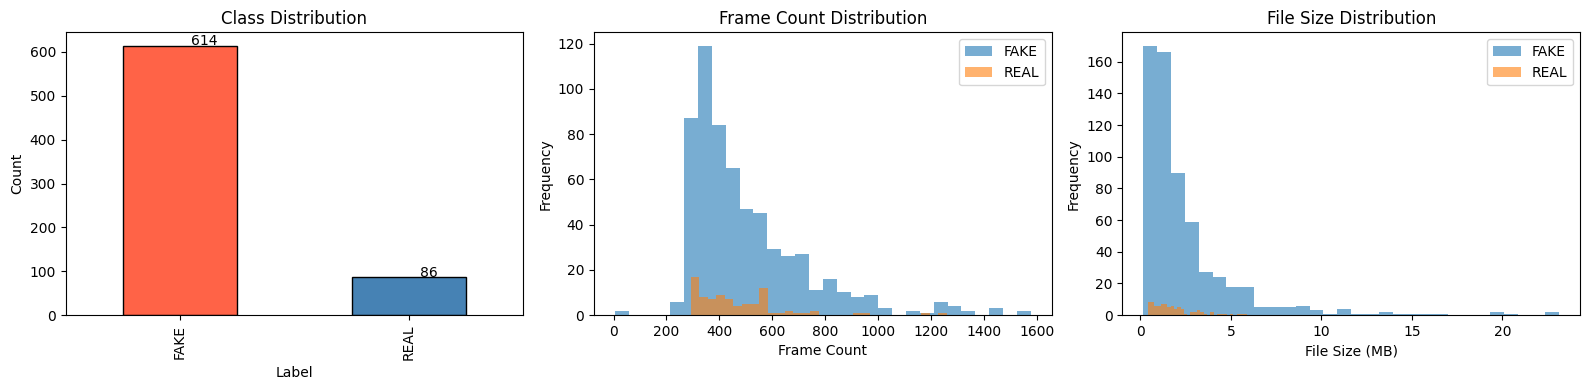

In [12]:
print('='*45)
print('DATASET OVERVIEW')
print('='*45)
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())
print('\nBasic statistics:')
print(df.describe())

# Class distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1 — class balance
df['Label'].value_counts().plot(kind='bar', ax=axes[0],
    color=['tomato','steelblue'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(str(p.get_height()),
        (p.get_x()+0.3, p.get_height()+2))

# Plot 2 — frame count distribution
df.groupby('Label')['Frame Count'].plot(
    kind='hist', ax=axes[1], alpha=0.6,
    bins=30, legend=True)
axes[1].set_title('Frame Count Distribution')
axes[1].set_xlabel('Frame Count')

# Plot 3 — file size distribution
df.groupby('Label')['File Size(MB)'].plot(
    kind='hist', ax=axes[2], alpha=0.6,
    bins=30, legend=True)
axes[2].set_title('File Size Distribution')
axes[2].set_xlabel('File Size (MB)')

plt.tight_layout()
plt.savefig('/content/data_exploration.png', dpi=150)
plt.show()

1. Feature Engineering & Selection

Features after engineering:
   Frame Count  log_frame_count  File Size(MB)  log_file_size  resolution  \
0          319         5.768321           0.79       0.582216      307200   
1          300         5.707110           2.65       1.294727     2073600   
2          763         6.638568           2.22       1.169381      314880   
3          407         6.011267           4.31       1.669592     2073600   
4          364         5.899897           0.56       0.444686      313920   
5          544         6.300786           1.03       0.708036      409920   
6          548         6.308098           5.54       1.877937     2073600   
7          554         6.318968           0.84       0.609766      307200   

   log_resolution  aspect_ratio  codec_enc      manip_type  
0       12.635258      1.333333          1       Deepfakes  
1       14.544797      1.777778          1  NeuralTextures  
2       12.659950      1.366667          1        FaceSwap  
3       14.544797      1.777778   

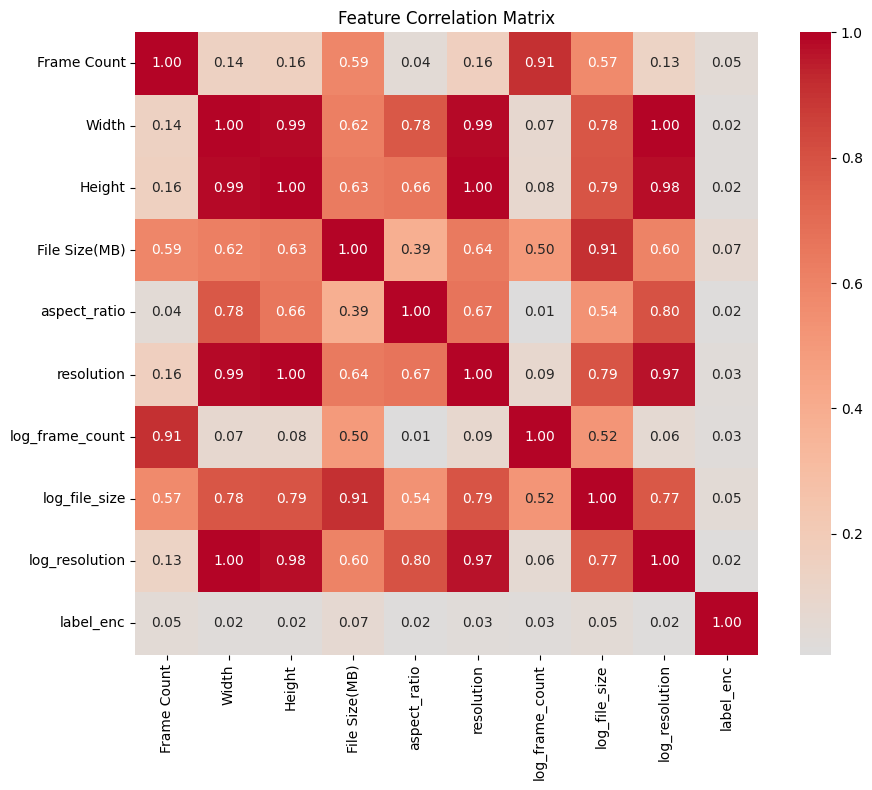

In [13]:
# ── Extract manipulation type from File Path ──
def get_manip_type(path):
    return Path(path).parts[0]   # e.g. "Deepfakes" from "Deepfakes/085_124.mp4"

df['manip_type'] = df['File Path'].apply(get_manip_type)

# ── Encode Codec (h264 is the only one but encode anyway) ──
df['codec_enc'] = (df['Codec'] == 'h264').astype(int)

# ── Aspect ratio feature ──
df['aspect_ratio'] = df['Width'] / df['Height']

# ── Resolution feature (total pixels) ──
df['resolution'] = df['Width'] * df['Height']

# ── Log-transform skewed features ──
df['log_frame_count'] = np.log1p(df['Frame Count'])
df['log_file_size']   = np.log1p(df['File Size(MB)'])
df['log_resolution']  = np.log1p(df['resolution'])

print('Features after engineering:')
print(df[['Frame Count','log_frame_count',
          'File Size(MB)','log_file_size',
          'resolution','log_resolution',
          'aspect_ratio','codec_enc','manip_type']].head(8))

# ── Check correlation with target ──
df['label_enc'] = (df['Label'] == 'FAKE').astype(int)
num_cols = ['Frame Count','Width','Height','File Size(MB)',
            'aspect_ratio','resolution','log_frame_count',
            'log_file_size','log_resolution']

print('\nCorrelation with target (FAKE=1):')
corr = df[num_cols + ['label_enc']].corr()['label_enc'].drop('label_enc')
print(corr.sort_values(ascending=False))

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols + ['label_enc']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('/content/correlation_heatmap.png', dpi=150)
plt.show()

2. Select Features & Target

In [14]:
# ── Selected features ──
# We use the engineered + original numerical features
# Drop raw redundant ones (log versions replace them)
FEATURES = [
    'log_frame_count',   # temporal length of video
    'log_file_size',     # compression artifacts proxy
    'log_resolution',    # spatial quality proxy
    'aspect_ratio',      # video format
    'codec_enc'          # encoding type
]

TARGET = 'label_enc'    # 0 = REAL, 1 = FAKE

X = df[FEATURES].values
y = df[TARGET].values

print('X shape :', X.shape)    # (700, 5)
print('y shape :', y.shape)    # (700,)
print('\nFeature matrix (first 5 rows):')
print(pd.DataFrame(X, columns=FEATURES).head())
print('\nTarget distribution:')
print(pd.Series(y).value_counts().rename({0:'REAL', 1:'FAKE'}))

X shape : (700, 5)
y shape : (700,)

Feature matrix (first 5 rows):
   log_frame_count  log_file_size  log_resolution  aspect_ratio  codec_enc
0         5.768321       0.582216       12.635258      1.333333        1.0
1         5.707110       1.294727       14.544797      1.777778        1.0
2         6.638568       1.169381       12.659950      1.366667        1.0
3         6.011267       1.669592       14.544797      1.777778        1.0
4         5.899897       0.444686       12.656897      1.362500        1.0

Target distribution:
FAKE    614
REAL     86
Name: count, dtype: int64


3. Train / Val / Test Split

In [15]:
from sklearn.model_selection import train_test_split

# ── First split: 85% train+val, 15% test ──
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)

# ── Second split: 70% train, 15% val (from the 85%) ──
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,    # 0.176 * 85% ≈ 15% of total
    stratify=y_temp, random_state=42)

print('Split sizes:')
print(f'  X_train : {X_train.shape}  | FAKE={y_train.sum()}  REAL={(y_train==0).sum()}')
print(f'  X_val   : {X_val.shape}   | FAKE={y_val.sum()}   REAL={(y_val==0).sum()}')
print(f'  X_test  : {X_test.shape}   | FAKE={y_test.sum()}   REAL={(y_test==0).sum()}')
print(f'\n  Total   : {len(X_train)+len(X_val)+len(X_test)} ✅')

Split sizes:
  X_train : (490, 5)  | FAKE=430  REAL=60
  X_val   : (105, 5)   | FAKE=92   REAL=13
  X_test  : (105, 5)   | FAKE=92   REAL=13

  Total   : 700 ✅


4. Feature Scaling

Feature scaling applied (StandardScaler) ✅

Means (should be ~0 for train):
{'log_frame_count': np.float64(-0.0), 'log_file_size': np.float64(0.0), 'log_resolution': np.float64(0.0), 'aspect_ratio': np.float64(-0.0), 'codec_enc': np.float64(0.0)}

Stds (should be ~1 for train):
{'log_frame_count': np.float64(1.0), 'log_file_size': np.float64(1.0), 'log_resolution': np.float64(1.0), 'aspect_ratio': np.float64(1.0), 'codec_enc': np.float64(0.0)}


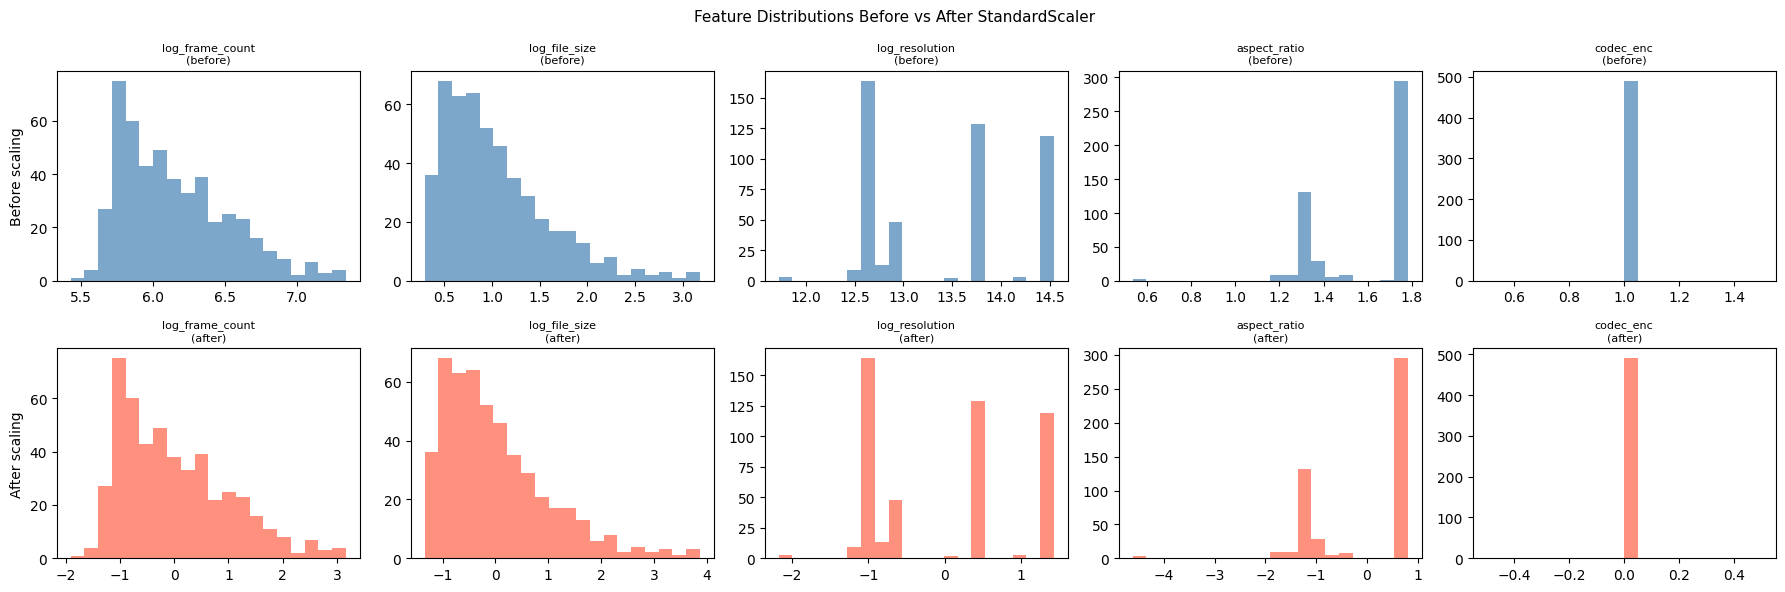

In [16]:
from sklearn.preprocessing import StandardScaler

# ── Fit ONLY on training data, transform all splits ──
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Feature scaling applied (StandardScaler) ✅')
print('\nMeans (should be ~0 for train):')
print(dict(zip(FEATURES, X_train_scaled.mean(axis=0).round(3))))
print('\nStds (should be ~1 for train):')
print(dict(zip(FEATURES, X_train_scaled.std(axis=0).round(3))))

# Before vs after scaling visualization
fig, axes = plt.subplots(2, len(FEATURES), figsize=(18, 6))
for i, feat in enumerate(FEATURES):
    axes[0][i].hist(X_train[:, i], bins=20, color='steelblue', alpha=0.7)
    axes[0][i].set_title(f'{feat}\n(before)', fontsize=8)
    axes[1][i].hist(X_train_scaled[:, i], bins=20, color='tomato', alpha=0.7)
    axes[1][i].set_title(f'{feat}\n(after)', fontsize=8)
axes[0][0].set_ylabel('Before scaling')
axes[1][0].set_ylabel('After scaling')
plt.suptitle('Feature Distributions Before vs After StandardScaler', fontsize=11)
plt.tight_layout()
plt.savefig('/content/feature_scaling.png', dpi=150)
plt.show()

5. Handle Class Imbalance

In [17]:
from sklearn.utils.class_weight import compute_class_weight

# ── Compute class weights (for model training) ──
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print('Class weights to pass to model:')
print(f'  REAL (0): {class_weights[0]:.4f}')
print(f'  FAKE (1): {class_weights[1]:.4f}')
print('\n(Higher weight on REAL because it is underrepresented)')

# Final summary
print('\n' + '='*45)
print('  PREPROCESSING COMPLETE ✅')
print('='*45)
print(f'  X_train_scaled : {X_train_scaled.shape}')
print(f'  X_val_scaled   : {X_val_scaled.shape}')
print(f'  X_test_scaled  : {X_test_scaled.shape}')
print(f'  y_train        : {y_train.shape}')
print(f'  y_val          : {y_val.shape}')
print(f'  y_test         : {y_test.shape}')
print(f'  Features used  : {FEATURES}')
print(f'  Class weights  : {class_weight_dict}')
print(f'  Scaler         : StandardScaler (fit on train only)')

Class weights to pass to model:
  REAL (0): 4.0833
  FAKE (1): 0.5698

(Higher weight on REAL because it is underrepresented)

  PREPROCESSING COMPLETE ✅
  X_train_scaled : (490, 5)
  X_val_scaled   : (105, 5)
  X_test_scaled  : (105, 5)
  y_train        : (490,)
  y_val          : (105,)
  y_test         : (105,)
  Features used  : ['log_frame_count', 'log_file_size', 'log_resolution', 'aspect_ratio', 'codec_enc']
  Class weights  : {0: np.float64(4.083333333333333), 1: np.float64(0.5697674418604651)}
  Scaler         : StandardScaler (fit on train only)


## 6 — Build Models

Baseline 1 — Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              precision_score, recall_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)

# ── Train ──
lr_model = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

# ── Validate ──
lr_val_prob = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_val_pred = (lr_val_prob > 0.5).astype(int)

print('='*45)
print('  BASELINE 1 — Logistic Regression')
print('='*45)
print(f'  Accuracy  : {accuracy_score(y_val, lr_val_pred):.4f}')
print(f'  Precision : {precision_score(y_val, lr_val_pred):.4f}')
print(f'  Recall    : {recall_score(y_val, lr_val_pred):.4f}')
print(f'  F1 Score  : {f1_score(y_val, lr_val_pred):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_val, lr_val_prob):.4f}')
print()
print(classification_report(y_val, lr_val_pred,
      target_names=['REAL', 'FAKE']))

  BASELINE 1 — Logistic Regression
  Accuracy  : 0.5333
  Precision : 0.9216
  Recall    : 0.5109
  F1 Score  : 0.6573
  AUC-ROC   : 0.6162

              precision    recall  f1-score   support

        REAL       0.17      0.69      0.27        13
        FAKE       0.92      0.51      0.66        92

    accuracy                           0.53       105
   macro avg       0.54      0.60      0.46       105
weighted avg       0.83      0.53      0.61       105



Baseline 2 — Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier

# ── Train ──
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# ── Validate ──
rf_val_prob = rf_model.predict_proba(X_val_scaled)[:, 1]
rf_val_pred = (rf_val_prob > 0.5).astype(int)

print('='*45)
print('  BASELINE 2 — Random Forest')
print('='*45)
print(f'  Accuracy  : {accuracy_score(y_val, rf_val_pred):.4f}')
print(f'  Precision : {precision_score(y_val, rf_val_pred):.4f}')
print(f'  Recall    : {recall_score(y_val, rf_val_pred):.4f}')
print(f'  F1 Score  : {f1_score(y_val, rf_val_pred):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_val, rf_val_prob):.4f}')
print()
print(classification_report(y_val, rf_val_pred,
      target_names=['REAL', 'FAKE']))

# ── Feature importance ──
print('Feature Importances:')
for feat, imp in sorted(zip(FEATURES, rf_model.feature_importances_),
                         key=lambda x: -x[1]):
    bar = '█' * int(imp * 50)
    print(f'  {feat:20s} : {imp:.4f}  {bar}')

  BASELINE 2 — Random Forest
  Accuracy  : 0.8381
  Precision : 0.8788
  Recall    : 0.9457
  F1 Score  : 0.9110
  AUC-ROC   : 0.5059

              precision    recall  f1-score   support

        REAL       0.17      0.08      0.11        13
        FAKE       0.88      0.95      0.91        92

    accuracy                           0.84       105
   macro avg       0.52      0.51      0.51       105
weighted avg       0.79      0.84      0.81       105

Feature Importances:
  log_file_size        : 0.4082  ████████████████████
  log_frame_count      : 0.3834  ███████████████████
  log_resolution       : 0.1105  █████
  aspect_ratio         : 0.0979  ████
  codec_enc            : 0.0000  


Baseline 3 — MLP (Neural Network)

In [20]:
from sklearn.neural_network import MLPClassifier

# ── Train ──
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp_model.fit(X_train_scaled, y_train)

# ── Validate ──
mlp_val_prob = mlp_model.predict_proba(X_val_scaled)[:, 1]
mlp_val_pred = (mlp_val_prob > 0.5).astype(int)

print('='*45)
print('  BASELINE 3 — MLP Neural Network')
print('='*45)
print(f'  Accuracy  : {accuracy_score(y_val, mlp_val_pred):.4f}')
print(f'  Precision : {precision_score(y_val, mlp_val_pred):.4f}')
print(f'  Recall    : {recall_score(y_val, mlp_val_pred):.4f}')
print(f'  F1 Score  : {f1_score(y_val, mlp_val_pred):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_val, mlp_val_prob):.4f}')
print()
print(classification_report(y_val, mlp_val_pred,
      target_names=['REAL', 'FAKE']))

  BASELINE 3 — MLP Neural Network
  Accuracy  : 0.8762
  Precision : 0.8762
  Recall    : 1.0000
  F1 Score  : 0.9340
  AUC-ROC   : 0.5117

              precision    recall  f1-score   support

        REAL       0.00      0.00      0.00        13
        FAKE       0.88      1.00      0.93        92

    accuracy                           0.88       105
   macro avg       0.44      0.50      0.47       105
weighted avg       0.77      0.88      0.82       105



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 7 — Compare All 3 Baselines

  BASELINE COMPARISON — VALIDATION SET
                     Accuracy      F1  AUC-ROC  Precision  Recall
Model                                                            
Logistic Regression    0.5333  0.6573   0.6162     0.9216  0.5109
Random Forest          0.8381  0.9110   0.5059     0.8788  0.9457
MLP                    0.8762  0.9340   0.5117     0.8762  1.0000

  Best baseline by AUC-ROC: Logistic Regression ✅


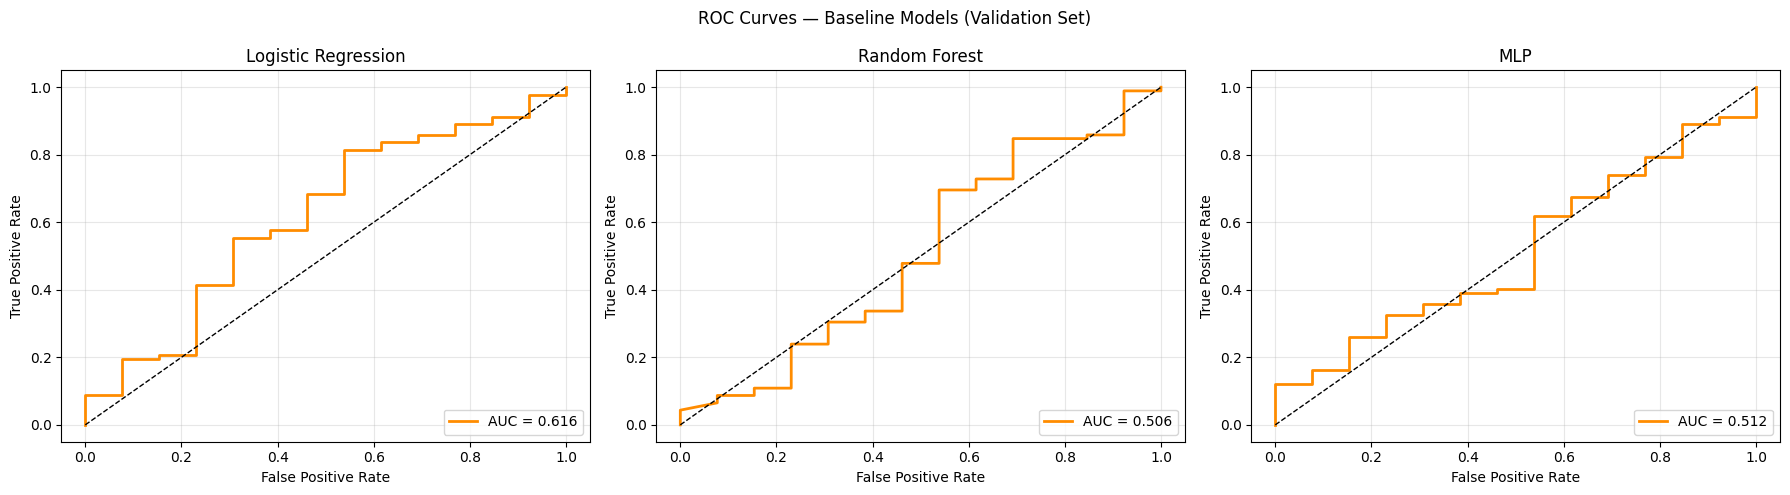

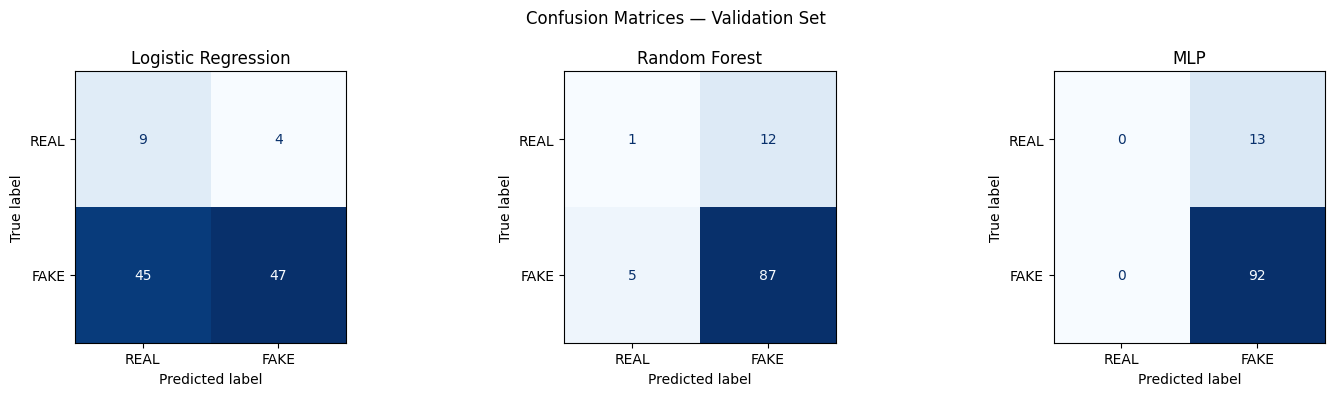

In [21]:
# ── Summary table ──
results = {
    'Model'    : ['Logistic Regression', 'Random Forest', 'MLP'],
    'Accuracy' : [accuracy_score(y_val, lr_val_pred),
                  accuracy_score(y_val, rf_val_pred),
                  accuracy_score(y_val, mlp_val_pred)],
    'F1'       : [f1_score(y_val, lr_val_pred),
                  f1_score(y_val, rf_val_pred),
                  f1_score(y_val, mlp_val_pred)],
    'AUC-ROC'  : [roc_auc_score(y_val, lr_val_prob),
                  roc_auc_score(y_val, rf_val_prob),
                  roc_auc_score(y_val, mlp_val_prob)],
    'Precision': [precision_score(y_val, lr_val_pred),
                  precision_score(y_val, rf_val_pred),
                  precision_score(y_val, mlp_val_pred)],
    'Recall'   : [recall_score(y_val, lr_val_pred),
                  recall_score(y_val, rf_val_pred),
                  recall_score(y_val, mlp_val_pred)],
}

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(4)
print('='*65)
print('  BASELINE COMPARISON — VALIDATION SET')
print('='*65)
print(results_df.to_string())
best_model_name = results_df['AUC-ROC'].idxmax()
print(f'\n  Best baseline by AUC-ROC: {best_model_name} ✅')

# ── ROC curves for all 3 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ('Logistic Regression', lr_val_prob, lr_val_pred),
    ('Random Forest',       rf_val_prob, rf_val_pred),
    ('MLP',                 mlp_val_prob, mlp_val_pred),
]

for i, (name, prob, pred) in enumerate(models_info):
    # ROC curve
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc_val      = roc_auc_score(y_val, prob)
    axes[i].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'AUC = {auc_val:.3f}')
    axes[i].plot([0,1],[0,1],'k--', lw=1)
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('ROC Curves — Baseline Models (Validation Set)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/baseline_roc_curves.png', dpi=150)
plt.show()

# ── Confusion matrices for all 3 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, prob, pred) in enumerate(models_info):
    cm = confusion_matrix(y_val, pred)
    ConfusionMatrixDisplay(cm, display_labels=['REAL','FAKE']).plot(
        ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}')
plt.suptitle('Confusion Matrices — Validation Set', fontsize=12)
plt.tight_layout()
plt.savefig('/content/baseline_confusion_matrices.png', dpi=150)
plt.show()

## 8 — Evaluate Models

In [22]:
# ── Evaluate all 3 on held-out test set ──
print('='*65)
print('  FINAL BASELINE RESULTS — TEST SET')
print('='*65)

test_results = {}
for name, model in [('Logistic Regression', lr_model),
                     ('Random Forest',       rf_model),
                     ('MLP',                 mlp_model)]:
    prob = model.predict_proba(X_test_scaled)[:, 1]
    pred = (prob > 0.5).astype(int)
    test_results[name] = {
        'Accuracy' : round(accuracy_score(y_test, pred), 4),
        'F1'       : round(f1_score(y_test, pred), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, prob), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall'   : round(recall_score(y_test, pred), 4),
    }
    print(f'\n  {name}:')
    for metric, val in test_results[name].items():
        print(f'    {metric:10s}: {val}')

test_df = pd.DataFrame(test_results).T
print('\n  Summary Table:')
print(test_df.to_string())

# Save results for paper comparison later
test_df.to_csv('/content/baseline_results.csv')
print('\nBaseline results saved to /content/baseline_results.csv ✅')
print('\nThese numbers are our benchmark to beat with the target model.')

  FINAL BASELINE RESULTS — TEST SET

  Logistic Regression:
    Accuracy  : 0.4476
    F1        : 0.5735
    AUC-ROC   : 0.51
    Precision : 0.8864
    Recall    : 0.4239

  Random Forest:
    Accuracy  : 0.8286
    F1        : 0.9043
    AUC-ROC   : 0.6472
    Precision : 0.8854
    Recall    : 0.9239

  MLP:
    Accuracy  : 0.8762
    F1        : 0.934
    AUC-ROC   : 0.6279
    Precision : 0.8762
    Recall    : 1.0

  Summary Table:
                     Accuracy      F1  AUC-ROC  Precision  Recall
Logistic Regression    0.4476  0.5735   0.5100     0.8864  0.4239
Random Forest          0.8286  0.9043   0.6472     0.8854  0.9239
MLP                    0.8762  0.9340   0.6279     0.8762  1.0000

Baseline results saved to /content/baseline_results.csv ✅

These numbers are our benchmark to beat with the target model.


## 9 — Make Prediction

## 10 — Save the Results